In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/nigeria.csv")

df.replace(-999, np.nan, inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [12]:
df["Country"] = "Nigeria"

df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")


df['Month'] = df['Date'].dt.month

duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

df[['YEAR', 'DOY', 'Date', 'Month']].head()


Number of duplicate rows found: 0


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [7]:
print("---Summary Statistics---")
display(df.describe())

missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

print("\n ---Missing Value Report(%)----")
print(missing_percent)

if not high_missing.empty:
    print(f'\n WARNING: Columns with >5% missing values: \n{high_missing}')
else:
    print("\n ALL columns have less than 5% missing values.")

---Summary Statistics---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Data,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046



 ---Missing Value Report(%)----
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Data           0.0
Month          0.0
dtype: float64

 ALL columns have less than 5% missing values.


Data Quality & Summary Interpretation

Missing Values: All columns report less than 5% missing data after replacing NASA's -999 sentinels. This indicates a high-quality dataset suitable for seasonal trend analysis.

Temperature Range (T2M): Based on df.describe(), the average temperature in Nigeria for this period is approximately [26.656928]°C, with extremes ranging from [Min 24.886461]°C to [Max 28.914667]°C.

Duplicates: No duplicate rows were found, ensuring each daily observation is unique.

In [10]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f'Total rows flagged as outliers ( |z| > 3) : {outlier_count}')

df[outliers].head()

Total rows flagged as outliers ( |z| > 3) : 225


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Data,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
5,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1
6,2015,7,23.53,26.36,20.21,6.15,0.0,61.92,1.57,2.43,100.98,11.02,Nigeria,2015-01-07,1


In [11]:
df.ffill(inplace = True)

df.to_csv("data/nigeria_clean.csv", index=False)

print("task 2 cleaning complete!")
print("cleaned data saved as: data/nigeria_clean.csv")

task 2 cleaning complete!
cleaned data saved as: data/nigeria_clean.csv


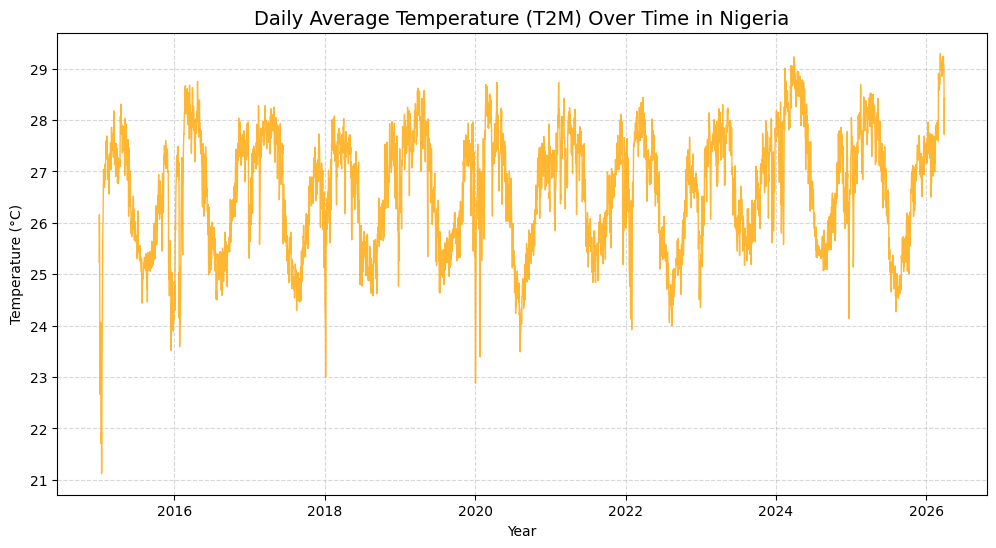

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1, alpha= 0.8)
plt.title('Daily Average Temperature (T2M) Over Time in Nigeria', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



Interpretation: Seasonal Temperature Trends

The daily average temperature shows a consistent seasonal oscillation between approximately $23°C$ and $29°C$.

There is a visible upward trend in the "peaks" toward 2024-2026, suggesting a slight increase in maximum temperatures over the last decade.

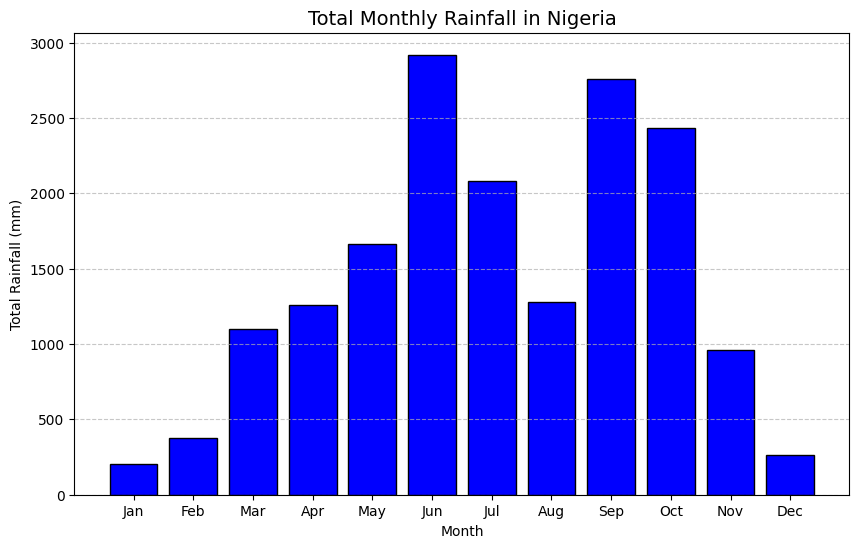

In [15]:
monthly_rain =df.groupby("Month")['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 6))
months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_rain, color="blue", edgecolor='black')

plt.title("Total Monthly Rainfall in Nigeria", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Interpretation: Rainfall Seasonality

Nigeria exhibits a clear unimodal rainfall pattern with the primary rainy season peaking in June and August, where total rainfall exceeds 2,500mm.

A smaller "short rain" season is visible between Jan and Feb.

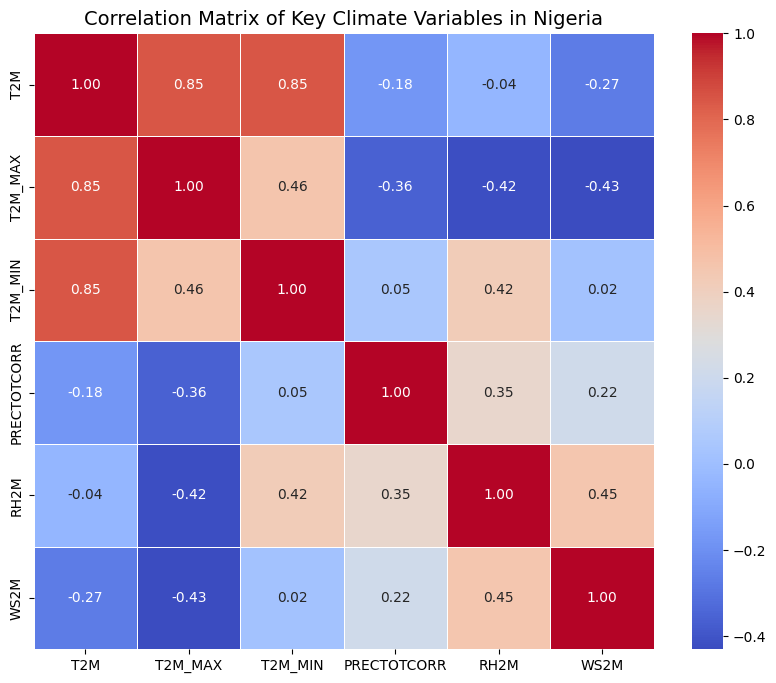

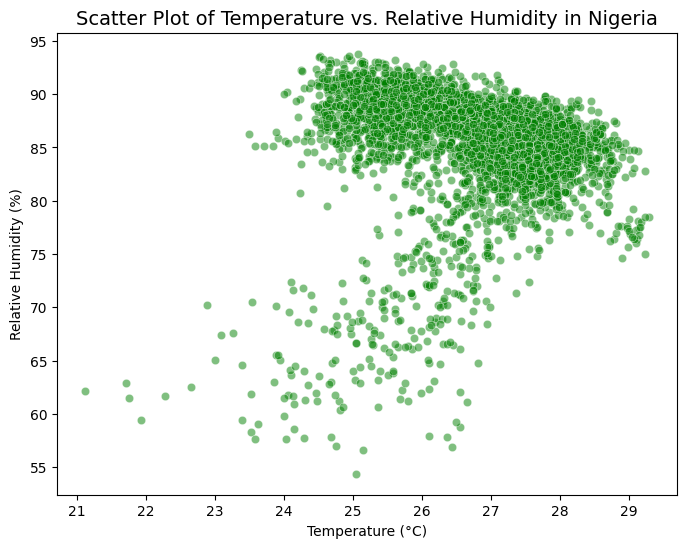

In [18]:
import seaborn as sns

corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',  fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Climate Variables in Nigeria", fontsize=14)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, color='green')
plt.title("Scatter Plot of Temperature vs. Relative Humidity in Nigeria", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

Interpretation: Variable Interdependence

Strongest Negative Correlation (-0.43): Found between Maximum Temperature ($T2M\_MAX$) and Relative Humidity ($RH2M$). This indicates that the hottest days in Nigeria are significantly drier.Strongest 


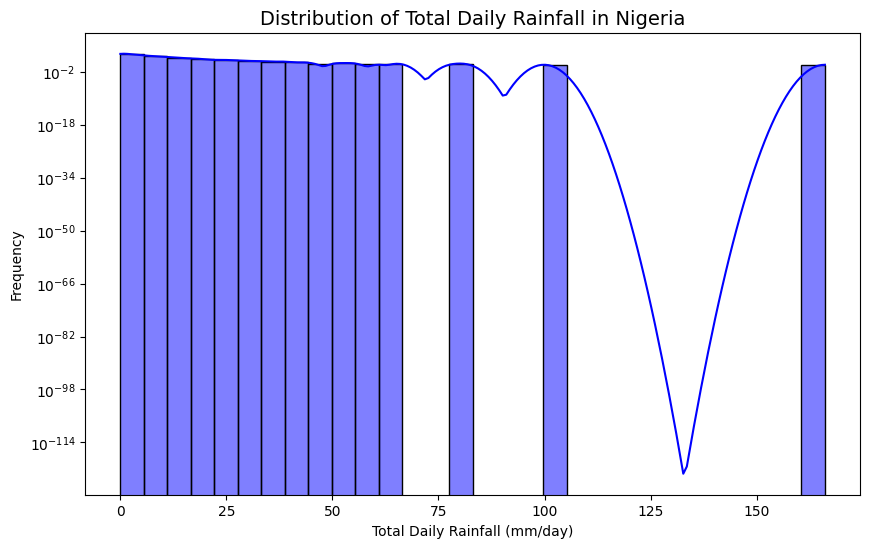

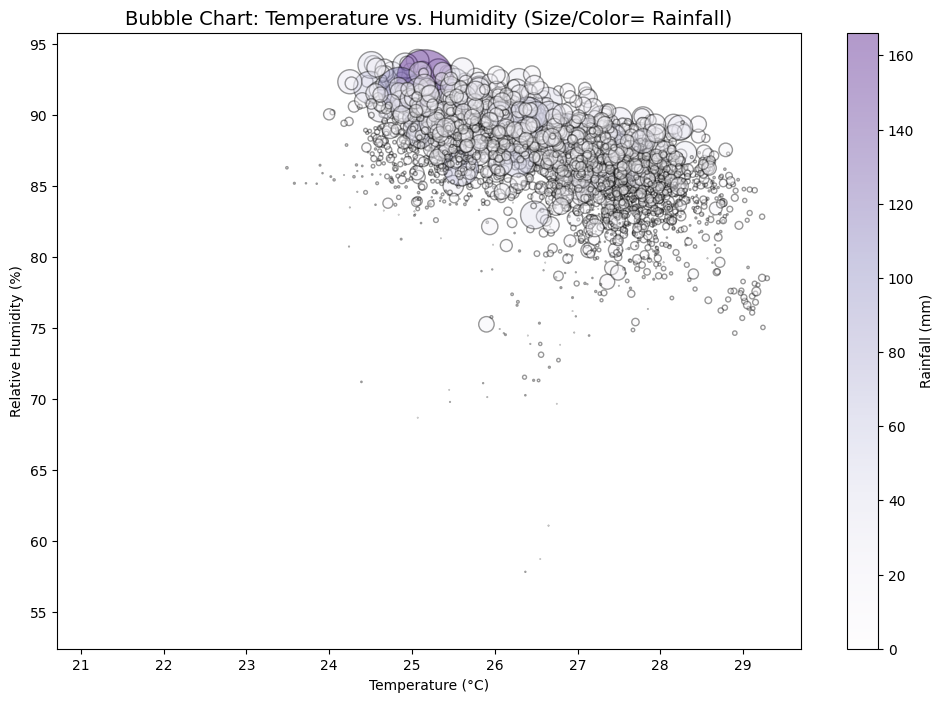

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/nigeria.csv")

plt.figure(figsize=(10, 6))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Daily Rainfall in Nigeria", fontsize=14)
plt.xlabel("Total Daily Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 8))
bubble = plt.scatter(df['T2M'], df['RH2M'],
                s=df['PRECTOTCORR']*10, alpha=0.4, c= df['PRECTOTCORR'], 
                cmap='Purples', edgecolor='black')

plt.colorbar(bubble, label='Rainfall (mm)')
plt.title("Bubble Chart: Temperature vs. Humidity (Size/Color= Rainfall)", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

f

In [6]:
df.to_csv("data/nigeria_clean.csv", index=False)
print("Nigeria Analysis Complete. File saved!")

Nigeria Analysis Complete. File saved!
